# QM Ch 1 — The Wave Function: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

This notebook generates all figures for the Chapter 1 lecture slides.

| Fig | Topic | Section |
|-----|-------|---------|
| 1 | Wave function & probability density $|\Psi(x,t)|^2$ | §1.1–1.2 |
| 2 | Gaussian wave packet — normalization | §1.4 |
| 3 | Discrete probability distribution | §1.3.1 |
| 4 | Continuous probability density | §1.3.2 |
| 5 | Expectation value $\langle x\rangle$ and uncertainty $\sigma_x$ | §1.3–1.5 |
| 6 | Momentum-space wave function (Fourier pair) | §1.5 |
| 7 | Uncertainty principle — $\sigma_x\sigma_p \geq \hbar/2$ | §1.6 |
| 8 | Wave function collapse | §1.2 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy.fft import fft, fftfreq, fftshift

# ── Dark theme matching qm_slides.css ──────────────────────────
BG    = '#1e1e2e'
BG2   = '#27273d'
FG    = '#cdd6f4'
MUTED = '#6c7086'
BLUE  = '#5b8dd9'   # accent  — primary
SKY   = '#89b4fa'   # accent2 — secondary
TEAL  = '#74c7ec'   # accent3 — emphasis
MAUVE = '#cba6f7'   # accent4 — math vars
GREEN = '#a6e3a1'
AMBER = '#f9e2af'
RED   = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG2,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   FG,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'text.color':        FG,
    'grid.color':        '#313244',
    'grid.linewidth':    0.5,
    'grid.alpha':        0.6,
    'font.family':       'sans-serif',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'legend.fontsize':   10,
    'legend.facecolor':  BG2,
    'legend.edgecolor':  MUTED,
    'lines.linewidth':   2.0,
    'figure.dpi':        130,
})

DPI    = 150
SAVEKW = dict(dpi=DPI, bbox_inches='tight', facecolor=BG)

print('Setup complete.')

Setup complete.


## Fig 1 — Wave function and probability density

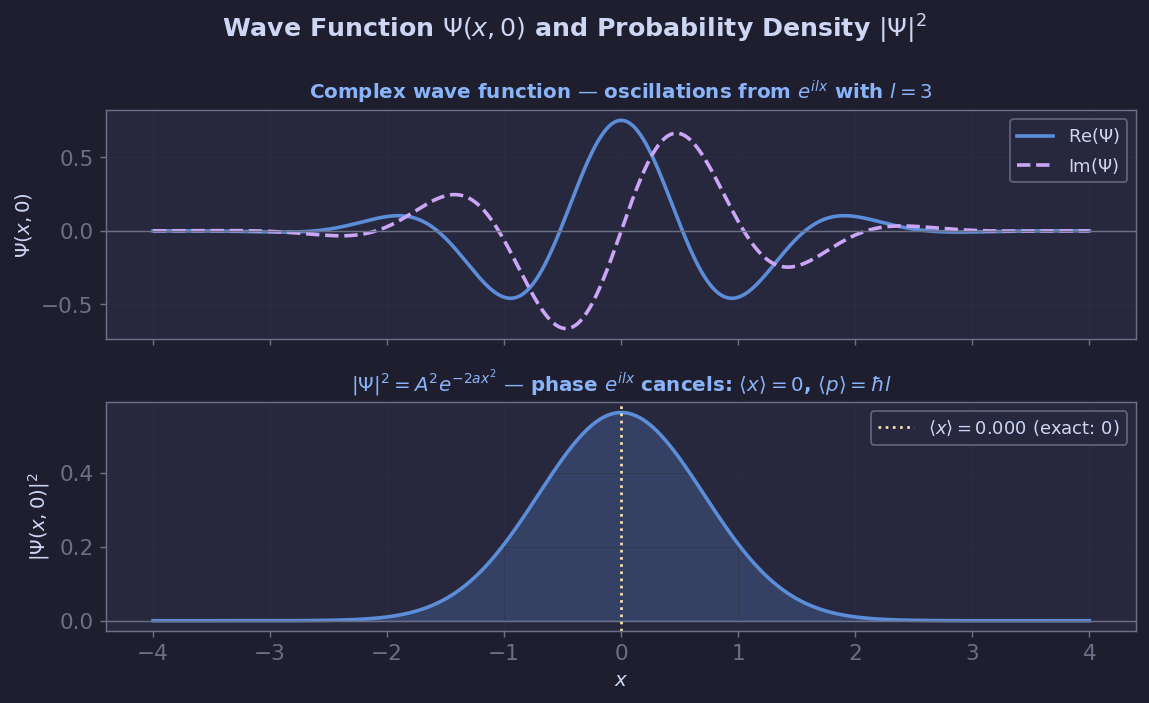

Fig 1 saved.  <x>=0.000000 (exact: 0),  sigma_x=0.7071
  <p>/hbar = l = 3.0  (momentum expectation, not position)


In [2]:
# Gaussian wave packet Ψ(x,0) = A exp(-ax²) exp(ilx)
#
# |Ψ|² = A² exp(-2ax²)  — the phase exp(ilx) drops out of |·|²
# Therefore:  <x> = 0  (|Ψ|² is even, centred at x=0)
#             <p> = ℏl  (l shifts the momentum distribution)
#             σ_x = 1/(2√a)
x  = np.linspace(-4, 4, 1000)
a  = 0.5
l  = 3.0
A  = (2*a/np.pi)**0.25
Psi  = A * np.exp(-a*x**2) * np.exp(1j*l*x)
prob = np.abs(Psi)**2

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
fig.suptitle(r'Wave Function $\Psi(x,0)$ and Probability Density $|\Psi|^2$',
             color=FG, fontsize=14, fontweight='bold')

# Top: Re and Im of Ψ
ax = axes[0]
ax.plot(x, Psi.real, color=BLUE,  label=r'$\mathrm{Re}(\Psi)$')
ax.plot(x, Psi.imag, color=MAUVE, label=r'$\mathrm{Im}(\Psi)$', linestyle='--')
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_ylabel(r'$\Psi(x,0)$')
ax.legend(loc='upper right')
ax.grid(True)
ax.set_title('Complex wave function — oscillations from $e^{ilx}$ with $l=3$',
             color=SKY, fontsize=11)

# Bottom: |Ψ|²
ax2 = axes[1]
ax2.fill_between(x, prob, alpha=0.25, color=BLUE)
ax2.plot(x, prob, color=BLUE)
ax2.axhline(0, color=MUTED, lw=0.8)

# <x> = 0 exactly (phase cancels in |Ψ|²)
x_mean = np.trapezoid(x * prob, x)
ax2.axvline(x_mean, color=AMBER, lw=1.5, linestyle=':',
            label=fr'$\langle x\rangle={x_mean:.3f}$ (exact: $0$)')

ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$|\Psi(x,0)|^2$')
ax2.legend(loc='upper right')
ax2.grid(True)
ax2.set_title(r'$|\Psi|^2 = A^2 e^{-2ax^2}$ — phase $e^{ilx}$ cancels: $\langle x\rangle=0$, $\langle p\rangle=\hbar l$',
              color=SKY, fontsize=11)

fig.tight_layout()
plt.savefig('ch01_fig1_wave_function.png', **SAVEKW)
plt.show()
print(f'Fig 1 saved.  <x>={x_mean:.6f} (exact: 0),  sigma_x={1/(2*np.sqrt(a)):.4f}')
print(f'  <p>/hbar = l = {l}  (momentum expectation, not position)')


## Fig 2 — Gaussian wave packet: normalization

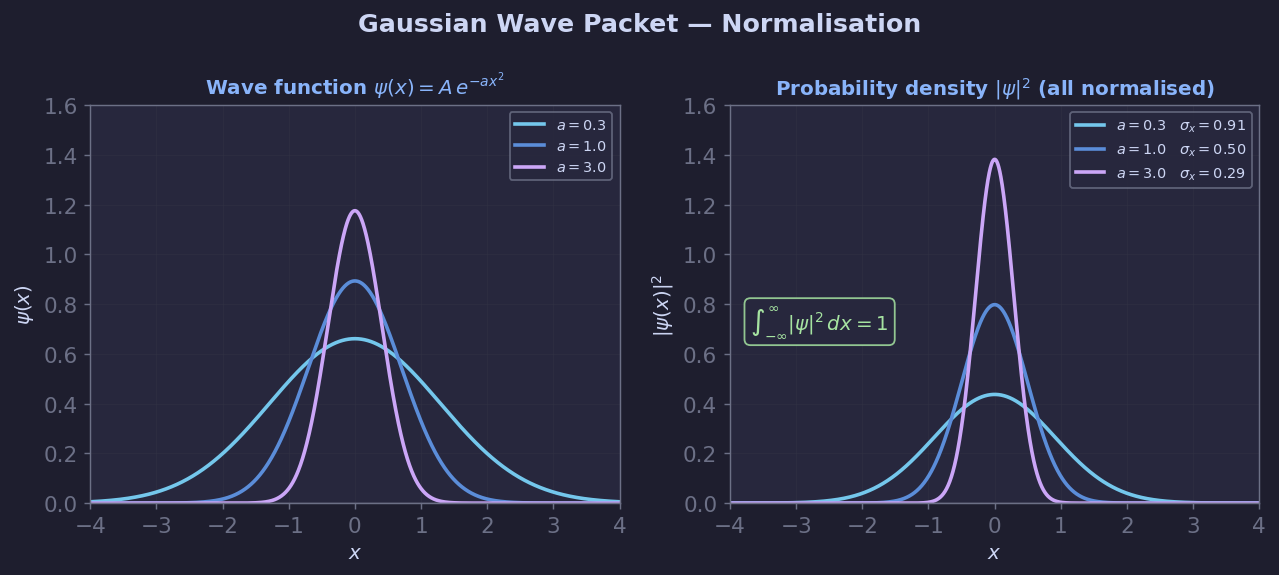

Fig 2 saved.


In [3]:
# Three Gaussians: show that ALL are normalised to 1,
# but differ in width (σ_x) and peak height.
# Physics: A = (2a/π)^(1/4)  ensures  ∫|ψ|²dx = 1  exactly.
x = np.linspace(-4, 4, 2000)
params = [
    (0.3, TEAL,  r'$a=0.3$'),
    (1.0, BLUE,  r'$a=1.0$'),
    (3.0, MAUVE, r'$a=3.0$'),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Gaussian Wave Packet — Normalisation',
             color=FG, fontsize=14, fontweight='bold')

for a, col, lbl in params:
    A    = (2*a/np.pi)**0.25
    psi  = A * np.exp(-a*x**2)          # real Gaussian (l=0)
    prob = psi**2
    #norm = np.trapezoid(prob, x)
    sigma_x = 1 / (2*np.sqrt(a))
    axes[0].plot(x, psi,  color=col, label=lbl)
    axes[1].plot(x, prob, color=col,
                 label=fr'{lbl}   $\sigma_x={sigma_x:.2f}$')

for ax, ylabel, title in zip(axes,
        [r'$\psi(x)$', r'$|\psi(x)|^2$'],
        [r'Wave function $\psi(x)=A\,e^{-ax^2}$',
         r'Probability density $|\psi|^2$ (all normalised)' ]):
    ax.axhline(0, color=MUTED, lw=0.8)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(ylabel)
    ax.set_title(title, color=SKY, fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True)
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 1.6)

# Annotation: normalisation condition — use axes fraction coords (0..1)
axes[1].text(0.3, 0.5,
             r'$\int_{-\infty}^{\infty}|\psi|^2\,dx=1$',
             color=GREEN, fontsize=11, ha='right', va='top',
             transform=axes[1].transAxes,
             bbox=dict(boxstyle='round,pad=0.3',
                       facecolor=BG2, edgecolor=GREEN, alpha=0.85))

fig.tight_layout()
plt.savefig('ch01_fig2_normalization.png', **SAVEKW)
plt.show()
print('Fig 2 saved.')


## Fig 3 — Discrete probability distribution (§1.3.1)

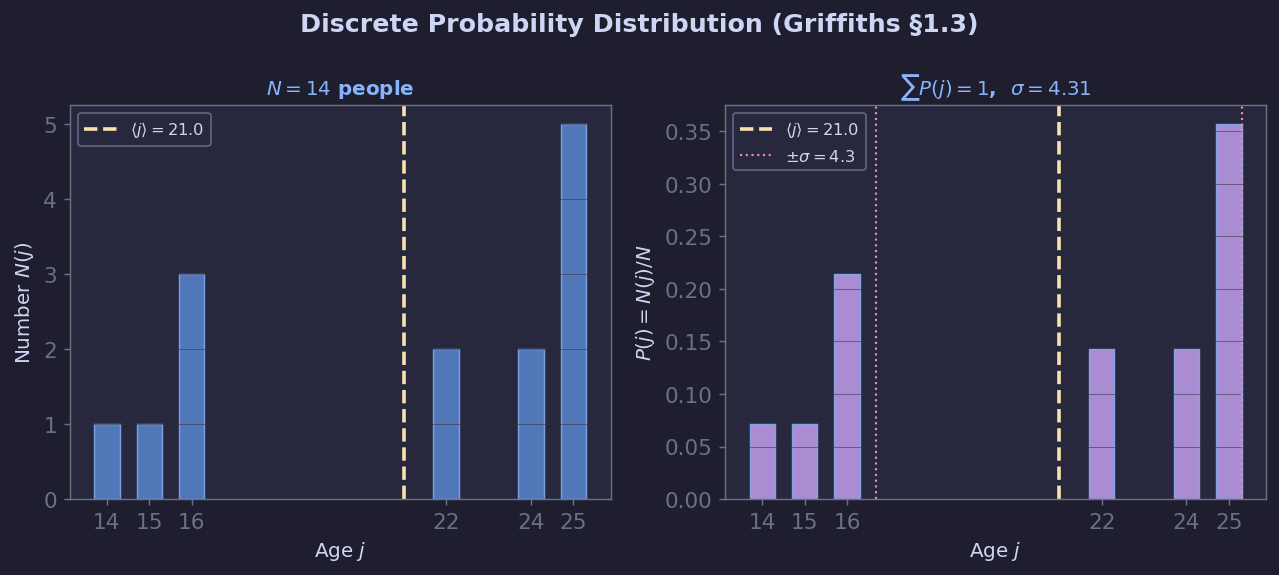

Fig 3 saved.  <j>=21.00, sigma=4.31


In [4]:
# Griffiths age example: N=14 people
ages   = np.array([14, 15, 16, 22, 24, 25])
counts = np.array([1,  1,  3,  2,  2,  5 ])
N_total = counts.sum()
prob    = counts / N_total

j_mean  = np.sum(ages * prob)
j2_mean = np.sum(ages**2 * prob)
sigma   = np.sqrt(j2_mean - j_mean**2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.suptitle('Discrete Probability Distribution (Griffiths §1.3)', color=FG, fontsize=14, fontweight='bold')

# Left: histogram
ax = axes[0]
bars = ax.bar(ages, counts, color=BLUE, alpha=0.8, edgecolor=SKY, linewidth=0.8, width=0.6)
ax.set_xlabel('Age $j$')
ax.set_ylabel('Number $N(j)$')
ax.set_title(f'$N={N_total}$ people', color=SKY, fontsize=11)
ax.axvline(j_mean, color=AMBER, lw=2, linestyle='--', label=fr'$\langle j\rangle={j_mean:.1f}$')
ax.set_xticks(ages)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Right: probability
ax2 = axes[1]
ax2.bar(ages, prob, color=MAUVE, alpha=0.8, edgecolor=SKY, linewidth=0.8, width=0.6)
ax2.axvline(j_mean, color=AMBER, lw=2, linestyle='--', label=fr'$\langle j\rangle={j_mean:.1f}$')
ax2.axvline(j_mean - sigma, color=RED, lw=1.2, linestyle=':', label=fr'$\pm\sigma={sigma:.1f}$')
ax2.axvline(j_mean + sigma, color=RED, lw=1.2, linestyle=':')
ax2.set_xlabel('Age $j$')
ax2.set_ylabel('$P(j) = N(j)/N$')
ax2.set_title(fr'$\sum P(j)=1$,  $\sigma={sigma:.2f}$', color=SKY, fontsize=11)
ax2.set_xticks(ages)
ax2.legend(fontsize=9)
ax2.grid(True, axis='y')

fig.tight_layout()
plt.savefig('ch01_fig3_discrete_prob.png', **SAVEKW)
plt.show()
print(f'Fig 3 saved.  <j>={j_mean:.2f}, sigma={sigma:.2f}')

## Fig 4 — Expectation value and uncertainty σ_x (§1.3–1.5)

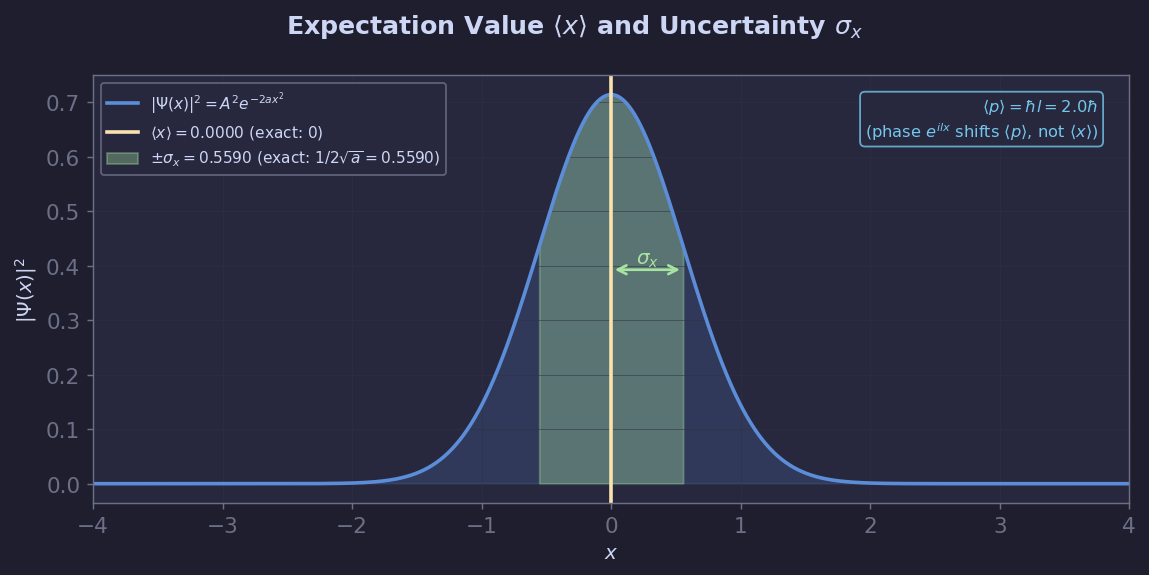

Fig 4 saved.  <x>=0.000000 (exact 0),  σ_x=0.559017 (exact 0.559017)
  Physics check: <p>/hbar = l = 2.0  [momentum expectation]


In [5]:
x = np.linspace(-6, 6, 2000)
a = 0.8
l = 2.0
A = (2*a/np.pi)**0.25
Psi  = A * np.exp(-a*x**2) * np.exp(1j*l*x)
prob = np.abs(Psi)**2

# Exact values for Ψ = A exp(-ax²) exp(ilx):
#   |Ψ|² = A² exp(-2ax²)  — even, centred at x = 0
#   <x>   = 0             — NOT l/(2a)  [that would be for a shifted real Gaussian]
#   <x²>  = 1/(4a)
#   σ_x   = 1/(2√a)
#   <p>   = ℏl            — l shifts momentum, not position
x_mean_exact  = 0.0
sigma_x_exact = 1 / (2*np.sqrt(a))

x_mean  = np.trapezoid(x * prob, x)
x2_mean = np.trapezoid(x**2 * prob, x)
sigma_x = np.sqrt(x2_mean - x_mean**2)

fig, ax = plt.subplots(figsize=(9, 4.5))
fig.suptitle(r'Expectation Value $\langle x\rangle$ and Uncertainty $\sigma_x$',
             color=FG, fontsize=14, fontweight='bold')

ax.fill_between(x, prob, alpha=0.18, color=BLUE)
ax.plot(x, prob, color=BLUE, lw=2, label=r'$|\Psi(x)|^2 = A^2 e^{-2ax^2}$')

ax.axvline(x_mean, color=AMBER, lw=2,
           label=fr'$\langle x\rangle = {x_mean:.4f}$ (exact: $0$)')

mask = (x >= x_mean - sigma_x) & (x <= x_mean + sigma_x)
ax.fill_between(x[mask], prob[mask], alpha=0.35, color=GREEN,
                label=fr'$\pm\sigma_x = {sigma_x:.4f}$ (exact: $1/2\sqrt{{a}}={sigma_x_exact:.4f}$)')

y_arr = prob.max() * 0.55
ax.annotate('', xy=(x_mean + sigma_x, y_arr), xytext=(x_mean, y_arr),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=1.5))
ax.text(x_mean + sigma_x/2, y_arr + 0.01,
        r'$\sigma_x$', color=GREEN, ha='center', fontsize=11)

# Note: <p> = hbar * l
ax.text(0.97, 0.95,
        fr'$\langle p\rangle = \hbar l = {l}\hbar$' + '\n' + r'(phase $e^{ilx}$ shifts $\langle p\rangle$, not $\langle x\rangle$)',
        color=TEAL, fontsize=9, ha='right', va='top',
        transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor=BG2, edgecolor=TEAL, alpha=0.8))

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$|\Psi(x)|^2$')
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(True)
ax.set_xlim(-4, 4)

fig.tight_layout()
plt.savefig('ch01_fig4_expectation_uncertainty.png', **SAVEKW)
plt.show()
print(f'Fig 4 saved.  <x>={x_mean:.6f} (exact 0),  σ_x={sigma_x:.6f} (exact {sigma_x_exact:.6f})')
print(f'  Physics check: <p>/hbar = l = {l}  [momentum expectation]')


## Fig 5 — Momentum-space wave function: Fourier pair (§1.5)

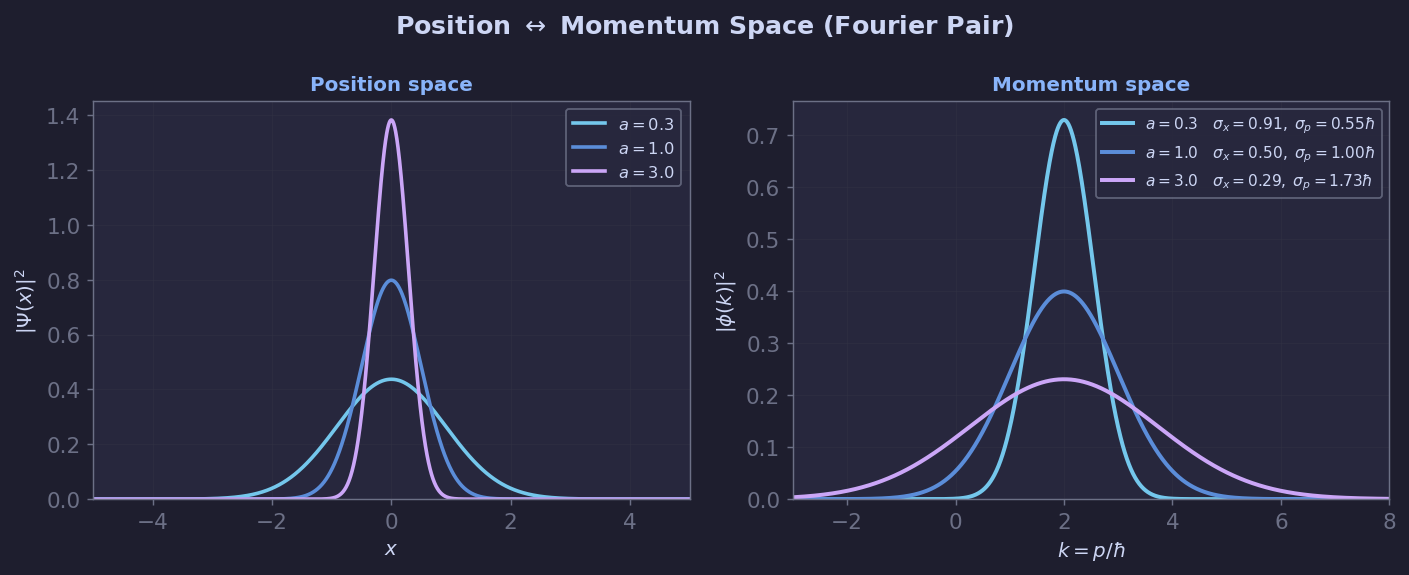

Fig 5 saved (analytic — perfectly smooth).


In [6]:
# Position-space Gaussian → momentum-space Gaussian (analytic Fourier transform)
#
# Ψ(x) = A exp(-ax²) exp(ilx),   A = (2a/π)^(1/4)
#
# Exact Fourier transform:
#   φ(k) = (1/(2πa))^(1/4) exp(-(k-l)²/(4a))
#
# σ_x = 1/(2√a),  σ_p = ℏ√a  →  σ_x σ_p = ℏ/2  (minimum uncertainty)

x = np.linspace(-5, 5, 2000)
k = np.linspace(-3, 8, 2000)
l = 2.0   # central momentum (de Broglie: p₀ = ℏl)

a_vals = [0.3,  1.0,  3.0]
colors = [TEAL, BLUE, MAUVE]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(r'Position $\leftrightarrow$ Momentum Space (Fourier Pair)',
             color=FG, fontsize=14, fontweight='bold')

for a, col in zip(a_vals, colors):
    sigma_x = 1 / (2*np.sqrt(a))
    sigma_p = np.sqrt(a)           # ℏ units

    # |Ψ(x)|²
    A_x    = (2*a/np.pi)**0.25
    prob_x = (A_x * np.exp(-a*x**2))**2

    # |φ(k)|²  — analytic (perfectly smooth, no FFT artefacts)
    A_k    = (1/(2*np.pi*a))**0.25
    prob_k = (A_k * np.exp(-(k - l)**2 / (4*a)))**2

    axes[0].plot(x, prob_x, color=col, lw=2,
                 label=fr'$a={a}$')
    axes[1].plot(k, prob_k, color=col, lw=2.2,
                 label=fr'$a={a}$   $\sigma_x={sigma_x:.2f},\;\sigma_p={sigma_p:.2f}\hbar$')

# Left panel
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$|\Psi(x)|^2$')
axes[0].set_title('Position space', color=SKY, fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True)
axes[0].set_xlim(-5, 5)
axes[0].set_ylim(bottom=0)

# Right panel
axes[1].set_xlabel(r'$k = p/\hbar$')
axes[1].set_ylabel(r'$|\phi(k)|^2$')
axes[1].set_title('Momentum space', color=SKY, fontsize=11)
axes[1].legend(fontsize=8.5)
axes[1].grid(True)
axes[1].set_xlim(-3, 8)
axes[1].set_ylim(bottom=0)

# axes[1].text(0.03, 0.65,
#              r'Broad $\Psi(x)$ $\Rightarrow$ narrow $\phi(k)$, and vice versa',
#              color=AMBER, fontsize=9, va='top', transform=axes[1].transAxes)

fig.tight_layout()
plt.savefig('ch01_fig5_fourier_pair.png', **SAVEKW)
plt.show()
print('Fig 5 saved (analytic — perfectly smooth).')

## Fig 6 — Uncertainty principle: σ_x σ_p ≥ ℏ/2 (§1.6)

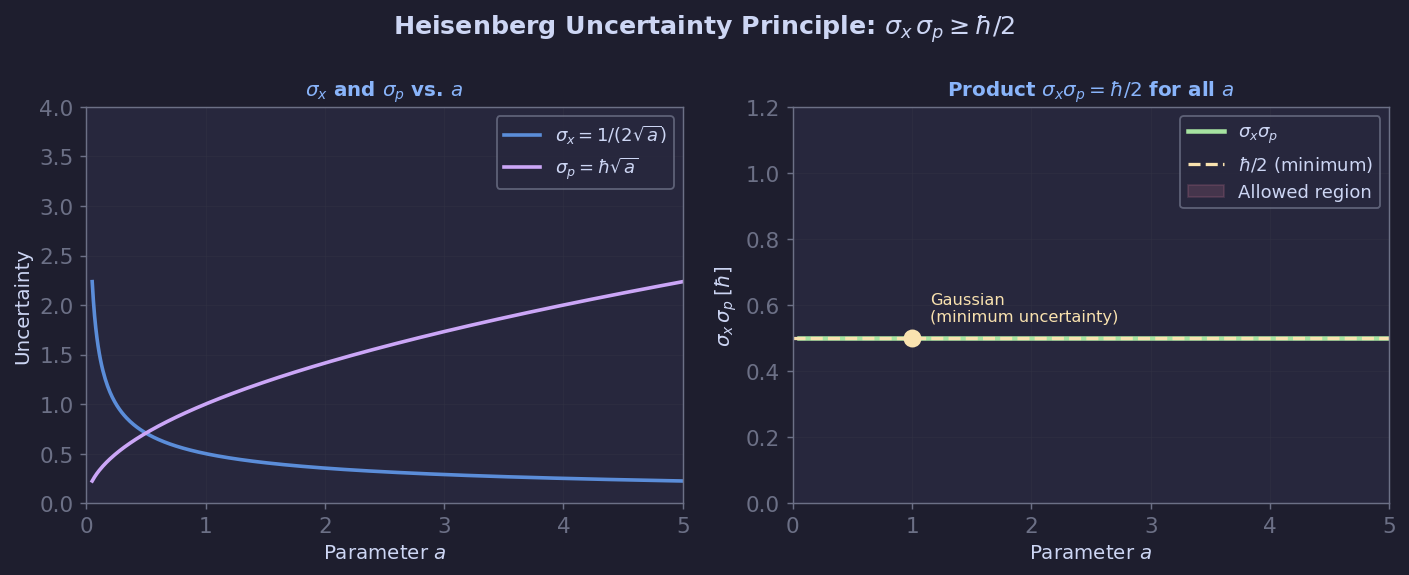

Fig 6 saved.


In [7]:
# For Gaussian: σ_x = 1/(2√a), σ_p = ℏ√a  →  σ_x σ_p = ℏ/2  (minimum!)
# Show the product as a function of a, and mark the minimum

a_range = np.linspace(0.05, 5, 500)
hbar = 1.0  # natural units
sigma_x = 1 / (2*np.sqrt(a_range))
sigma_p = hbar * np.sqrt(a_range)
product = sigma_x * sigma_p

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle(r'Heisenberg Uncertainty Principle: $\sigma_x\,\sigma_p \geq \hbar/2$',
             color=FG, fontsize=14, fontweight='bold')

# Left: σ_x and σ_p vs a
ax = axes[0]
ax.plot(a_range, sigma_x, color=BLUE,  lw=2, label=r'$\sigma_x = 1/(2\sqrt{a})$')
ax.plot(a_range, sigma_p, color=MAUVE, lw=2, label=r'$\sigma_p = \hbar\sqrt{a}$')
ax.set_xlabel('Parameter $a$')
ax.set_ylabel(r'Uncertainty')
ax.set_title(r'$\sigma_x$ and $\sigma_p$ vs. $a$', color=SKY, fontsize=11)
ax.legend()
ax.grid(True)
ax.set_ylim(0, 4)
ax.set_xlim(0, 5)

# Right: product σ_x σ_p
ax2 = axes[1]
ax2.plot(a_range, product, color=GREEN, lw=2.5, label=r'$\sigma_x\sigma_p$')
ax2.axhline(hbar/2, color=AMBER, lw=1.8, linestyle='--',
            label=r'$\hbar/2$ (minimum)')
ax2.fill_between(a_range, hbar/2, product, alpha=0.15, color=RED,
                 label='Allowed region')

# Mark minimum at a=1 for this parametrization (σ_x σ_p = ℏ/2 always)
a_min = 1.0
ax2.scatter([a_min], [hbar/2], color=AMBER, s=80, zorder=5)
ax2.text(a_min + 0.15, hbar/2 + 0.05,
         'Gaussian\n(minimum uncertainty)',
         color=AMBER, fontsize=9)

ax2.set_xlabel('Parameter $a$')
ax2.set_ylabel(r'$\sigma_x\,\sigma_p\;[\hbar]$')
ax2.set_title(r'Product $\sigma_x\sigma_p = \hbar/2$ for all $a$', color=SKY, fontsize=11)
ax2.legend()
ax2.grid(True)
ax2.set_ylim(0, 1.2)
ax2.set_xlim(0, 5)

fig.tight_layout()
plt.savefig('ch01_fig6_uncertainty_principle.png', **SAVEKW)
plt.show()
print('Fig 6 saved.')

## Fig 7 — Uncertainty principle: trade-off diagram

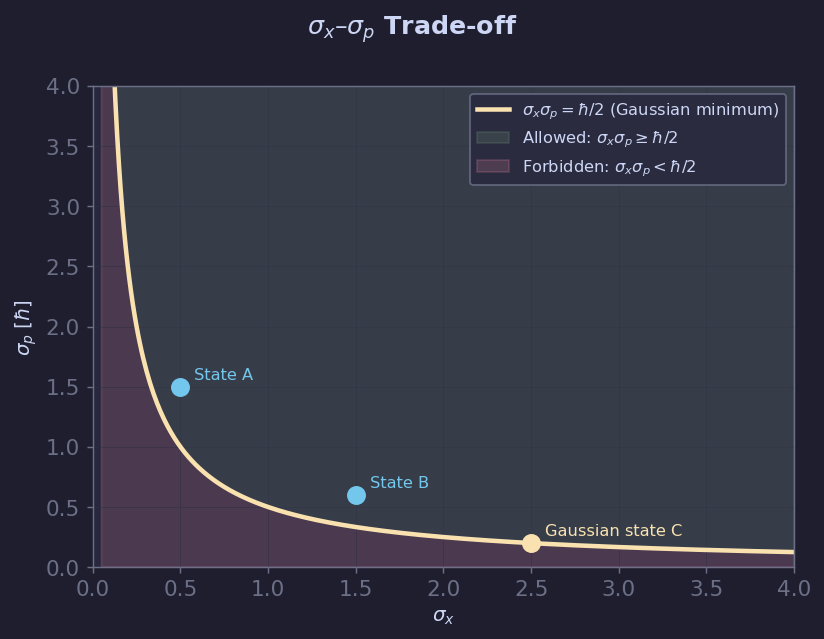

Fig 7 saved.


In [8]:
hbar = 1.0
sx = np.linspace(0.05, 4, 400)
sp_min = hbar / (2 * sx)   # boundary σ_x σ_p = ℏ/2

fig, ax = plt.subplots(figsize=(6.5, 5))
fig.suptitle(r'$\sigma_x$–$\sigma_p$ Trade-off',
             color=FG, fontsize=14, fontweight='bold')

ax.plot(sx, sp_min, color=AMBER, lw=2.5,
        label=r'$\sigma_x\sigma_p = \hbar/2$ (Gaussian minimum)')
ax.fill_between(sx, sp_min, 4, alpha=0.12, color=GREEN,
                label=r'Allowed: $\sigma_x\sigma_p \geq \hbar/2$')
ax.fill_between(sx, 0, sp_min, alpha=0.18, color=RED,
                label=r'Forbidden: $\sigma_x\sigma_p < \hbar/2$')

# Example states (all satisfy the bound)
examples = [
    (0.5, 1.5, 'State A', TEAL),
    (1.5, 0.6, 'State B', TEAL),
    (2.5, hbar/(2*2.5), 'Gaussian state C', AMBER),
]
for sx_e, sp_e, lbl, col in examples:
    ax.scatter(sx_e, sp_e, s=90, color=col, zorder=5)
    ax.text(sx_e + 0.08, sp_e + 0.06, lbl, color=col, fontsize=9)

# ax.text(0.55, 0.22, 'FORBIDDEN', color=RED, fontsize=13,
#         fontweight='bold', alpha=0.7, transform=ax.transAxes)
# ax.text(0.25, 0.72, 'ALLOWED', color=GREEN, fontsize=13,
#         fontweight='bold', alpha=0.7, transform=ax.transAxes)

ax.set_xlabel(r'$\sigma_x$')
ax.set_ylabel(r'$\sigma_p\;[\hbar]$')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True)
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)

fig.tight_layout()
plt.savefig('ch01_fig7_uncertainty_tradeoff.png', **SAVEKW)
plt.show()
print('Fig 7 saved.')


## Fig 8 — Wave function collapse (§1.2)

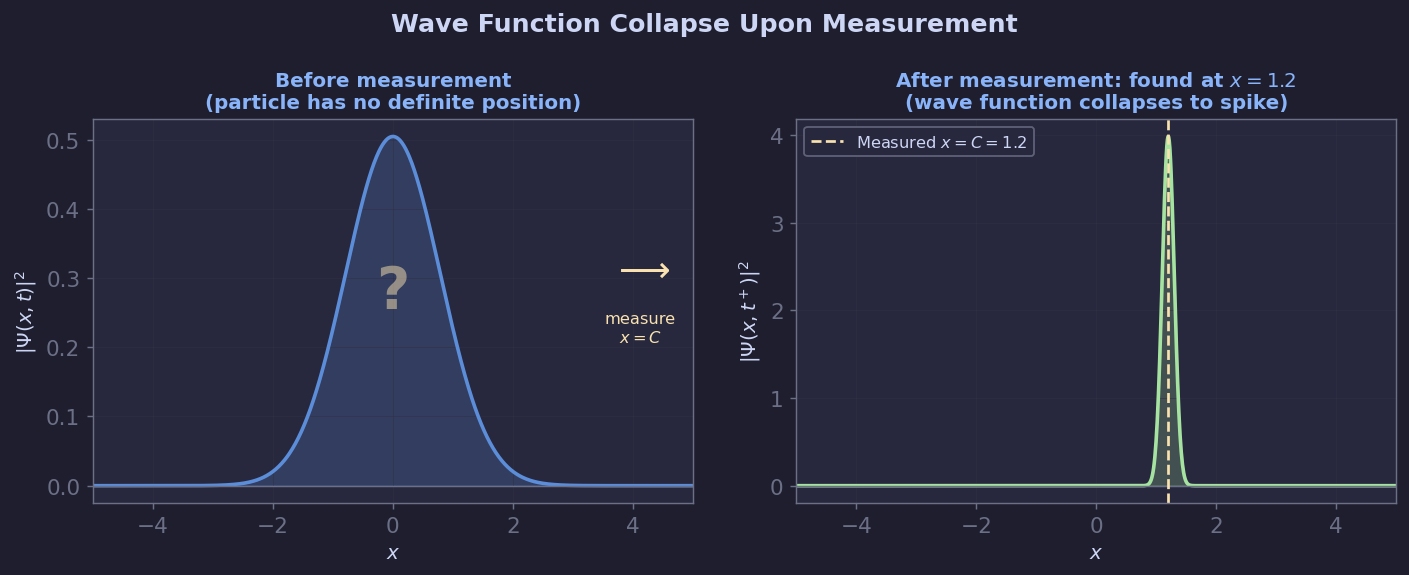

Fig 8 saved.


In [9]:
x = np.linspace(-5, 5, 1000)

# Before: broad Gaussian  ψ_before(x) = A exp(-a_b x²)
a_before = 0.4
A_before = (2*a_before/np.pi)**0.25
prob_before = (A_before * np.exp(-a_before*x**2))**2

# After: narrow Gaussian centred at C  (models collapsed state)
C = 1.2
a_after  = 25.0
A_after  = (2*a_after/np.pi)**0.25
prob_after = (A_after * np.exp(-a_after*(x - C)**2))**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Wave Function Collapse Upon Measurement',
             color=FG, fontsize=14, fontweight='bold')

# Before
ax = axes[0]
ax.fill_between(x, prob_before, alpha=0.22, color=BLUE)
ax.plot(x, prob_before, color=BLUE, lw=2)
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$|\Psi(x,t)|^2$')
ax.set_title('Before measurement\n(particle has no definite position)',
             color=SKY, fontsize=11)
ax.set_xlim(-5, 5)
ax.grid(True)
ax.text(0.5, 0.55, '?', color=AMBER, fontsize=32,
        ha='center', va='center', fontweight='bold', alpha=0.5,
        transform=ax.transAxes)

# After
ax2 = axes[1]
ax2.fill_between(x, prob_after, alpha=0.22, color=GREEN)
ax2.plot(x, prob_after, color=GREEN, lw=2)
ax2.axhline(0, color=MUTED, lw=0.8)
ax2.axvline(C, color=AMBER, lw=1.5, linestyle='--',
            label=fr'Measured $x = C = {C}$')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$|\Psi(x,t^+)|^2$')
ax2.set_title(rf'After measurement: found at $x = {C}$' '\n(wave function collapses to spike)',
              color=SKY, fontsize=11)
ax2.legend(fontsize=9)
ax2.set_xlim(-5, 5)
ax2.grid(True)

fig.text(0.455, 0.54, r'$\longrightarrow$', fontsize=20,
         color=AMBER, ha='center', va='center')
fig.text(0.455, 0.44, 'measure\n$x=C$', fontsize=9,
         color=AMBER, ha='center', va='center')

fig.tight_layout()
plt.savefig('ch01_fig8_collapse.png', **SAVEKW)
plt.show()
print('Fig 8 saved.')


## Summary — All figures

| File | Topic | Slide |
|------|-------|-------|
| `ch01_fig1_wave_function.png` | $\Psi(x,0)$ real/imag + $|\Psi|^2$ | §1.1–1.2 |
| `ch01_fig2_normalization.png` | Gaussian shapes + normalization | §1.4 |
| `ch01_fig3_discrete_prob.png` | Discrete distribution, $\langle j\rangle$, $\sigma$ | §1.3.1 |
| `ch01_fig4_expectation_uncertainty.png` | $\langle x\rangle$ and $\sigma_x$ on $|\Psi|^2$ | §1.3–1.5 |
| `ch01_fig5_fourier_pair.png` | Position ↔ momentum Fourier pair | §1.5 |
| `ch01_fig6_uncertainty_principle.png` | $\sigma_x\sigma_p = \hbar/2$ for Gaussian | §1.6 |
| `ch01_fig7_uncertainty_tradeoff.png` | $\sigma_x$–$\sigma_p$ allowed/forbidden region | §1.6 |
| `ch01_fig8_collapse.png` | Wave function collapse | §1.2 |

In [10]:
# ── Download all figures as a zip file ─────────────────────────
import zipfile, os, glob
from google.colab import files

zip_name = 'ch01_figures.zip'
fig_files = sorted(glob.glob('ch01_fig*.png'))

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn)
        print(f'  added: {fn}')

print(f'\nZip created: {zip_name}  ({os.path.getsize(zip_name)/1024:.0f} KB)')
files.download(zip_name)


  added: ch01_fig1_wave_function.png
  added: ch01_fig2_normalization.png
  added: ch01_fig3_discrete_prob.png
  added: ch01_fig4_expectation_uncertainty.png
  added: ch01_fig5_fourier_pair.png
  added: ch01_fig6_uncertainty_principle.png
  added: ch01_fig7_uncertainty_tradeoff.png
  added: ch01_fig8_collapse.png

Zip created: ch01_figures.zip  (624 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>